In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
# Load the dataset
df = pd.read_csv("loan_amount_prediction_dataset_v2.csv")
df.head()

,Age,Monthly_Income,Credit_Score,Loan_Tenure_Years,Existing_Loan_Amount,Num_of_Dependents,Loan_Amount
0,29,31515,777,16,465920,4,-31410
1,45,143962,722,22,253462,4,32523
2,24,122858,467,29,188059,2,35972
3,44,79131,813,26,452969,0,28036
4,36,112300,519,16,121038,3,51783


In [3]:

print(df.shape)
print(df.info())


(500, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Age                   500 non-null    int64
 1   Monthly_Income        500 non-null    int64
 2   Credit_Score          500 non-null    int64
 3   Loan_Tenure_Years     500 non-null    int64
 4   Existing_Loan_Amount  500 non-null    int64
 5   Num_of_Dependents     500 non-null    int64
 6   Loan_Amount           500 non-null    int64
dtypes: int64(7)
memory usage: 27.5 KB
None


In [4]:
df.isnull().sum()

Age                     0
Monthly_Income          0
Credit_Score            0
Loan_Tenure_Years       0
Existing_Loan_Amount    0
Num_of_Dependents       0
Loan_Amount             0
dtype: int64

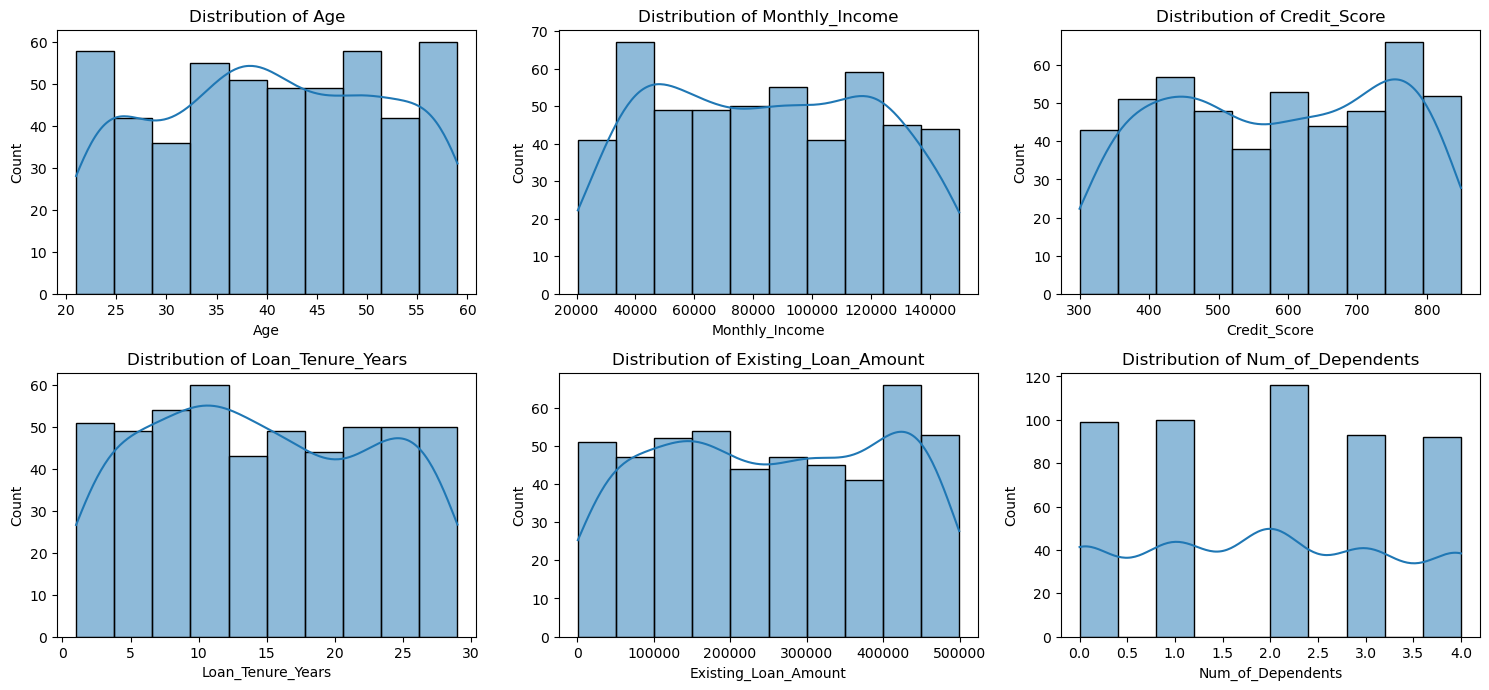

In [5]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(df.columns[:-1]):  # Exclude Loan_Amount (target)
    plt.subplot(3, 3, i+1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()


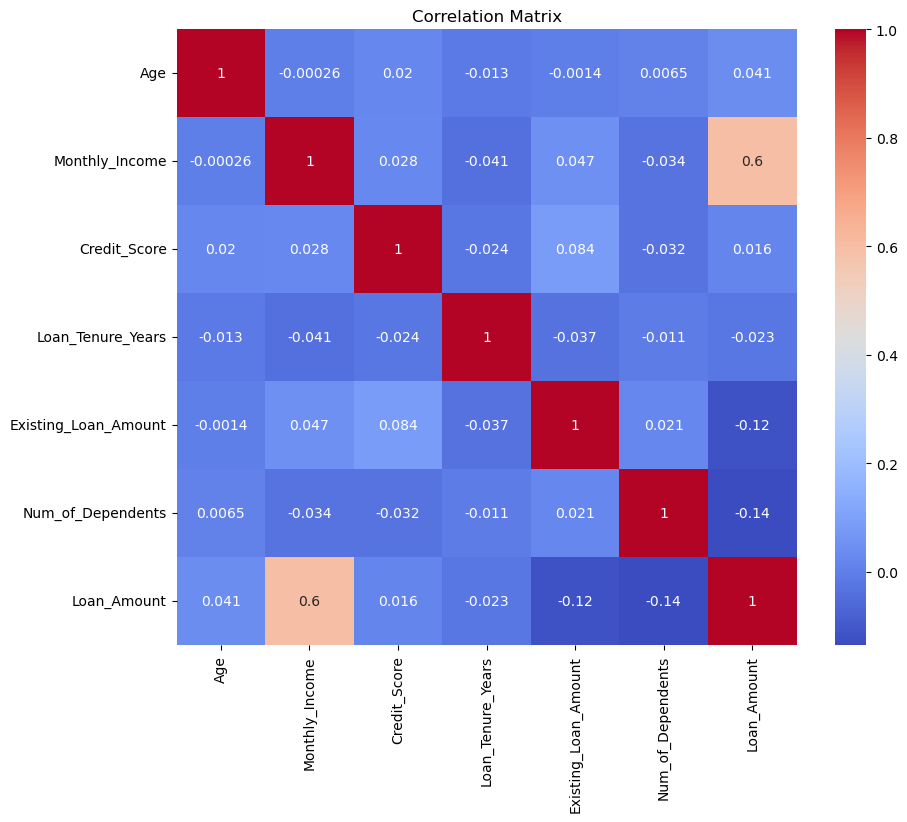

In [6]:
plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

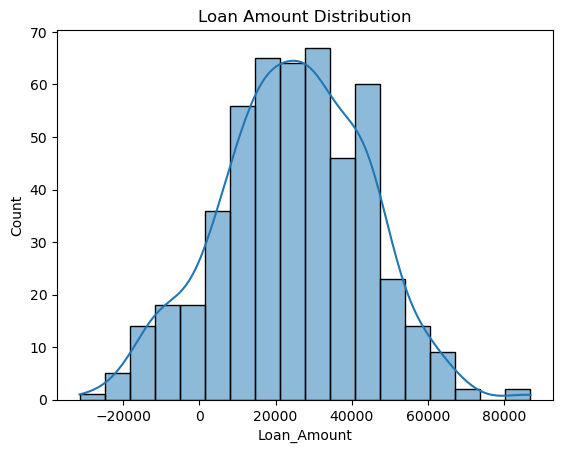

In [7]:
# Distribution of Loan Amount
sns.histplot(df['Loan_Amount'], kde=True)
plt.title("Loan Amount Distribution")
plt.show()




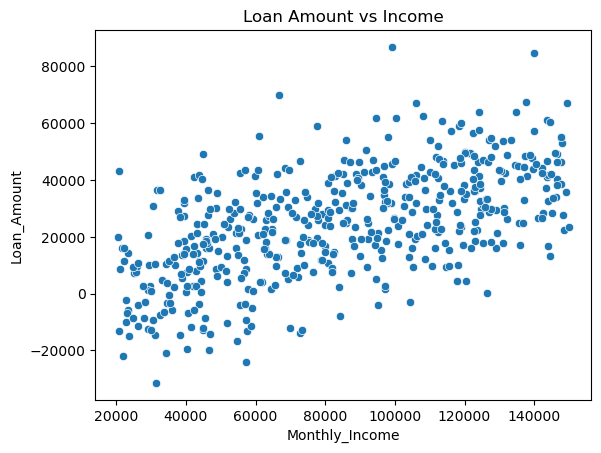

In [8]:
# Loan amount vs income
sns.scatterplot(x='Monthly_Income', y='Loan_Amount', data=df)
plt.title("Loan Amount vs Income")
plt.show()



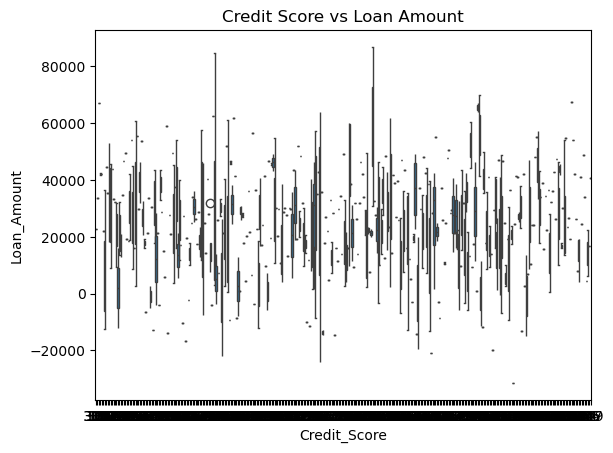

In [9]:
# Boxplot for credit score vs loan
sns.boxplot(x='Credit_Score', y='Loan_Amount', data=df)
plt.title("Credit Score vs Loan Amount")
plt.show()

<Axes: xlabel='Loan_Amount', ylabel='Count'>

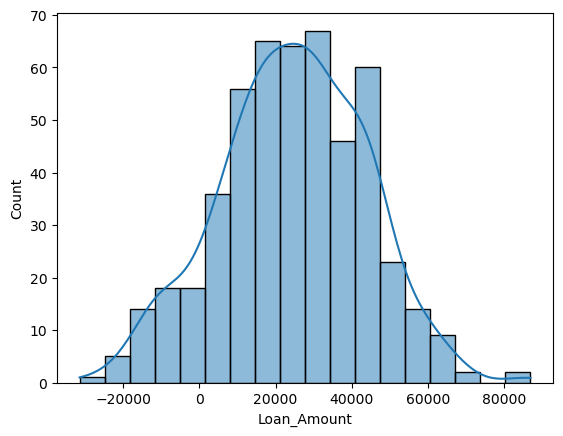

In [10]:
sns.histplot(df['Loan_Amount'], kde=True) 

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [12]:
df.columns

Index(['Age', 'Monthly_Income', 'Credit_Score', 'Loan_Tenure_Years',
       'Existing_Loan_Amount', 'Num_of_Dependents', 'Loan_Amount'],
      dtype='object')

In [13]:
features = ['Age', 'Monthly_Income', 'Credit_Score', 'Loan_Tenure_Years','Existing_Loan_Amount', 'Num_of_Dependents']
target = 'Loan_Amount'

X = df[features]
y = df[target]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [15]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [16]:

y_pred = model.predict(X_test)


In [17]:
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

Mean Absolute Error: 13259.887823345072
Mean Squared Error: 268044207.85729995
R² Score: 0.29715025023167274


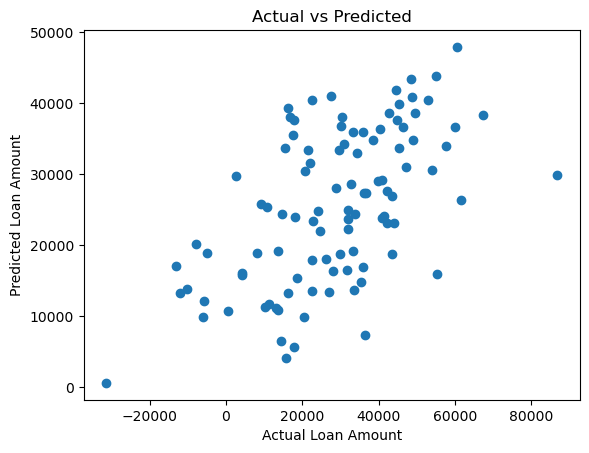

In [18]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Loan Amount")
plt.ylabel("Predicted Loan Amount")
plt.title("Actual vs Predicted")
plt.show()

In [19]:
pip install joblib


In [20]:
import joblib

# Save model
joblib.dump(model, 'loan_model.pkl')

# Optional: Save feature columns too (so you know input order)
joblib.dump(features, 'model_features.pkl')

['model_features.pkl']